# Financial Trading with Python, 2nd Edition
Cordell L. Tanny, CFA, FRM, FDP

## Chapter 4: Exploratory Data Analysis
### Notebook 4.3: Use Case - Visual Hypothesis Formation

Version: 1

Date of last revision: January 25, 2026

In this notebook, we apply the EDA techniques from Notebooks 4.1 and 4.2 to our volatility tail hedge use case. The goal is not to build a strategy yet, but to explore the data visually and form hypotheses about how these instruments behave and interact.

**Our instruments:**
- **SPY:** S&P 500 ETF (the asset we want to protect)
- **BIL:** Short-term Treasury ETF (cash proxy, safe haven)
- **VIXY:** VIX Short-Term Futures ETF (volatility exposure)
- **^VIX:** CBOE Volatility Index (market fear gauge)

**Important:** This notebook uses data files created in Notebook 3.3. If you saved the parquet file from that notebook, upload it to the Files section (left sidebar in Colab) **before running** this notebook. If the file is not found, the notebook will download fresh data automatically.

*Note and recommendation: Very often, you might want to experiment on your own as you go through this notebook. We recommend you save a copy of this notebook before you start adding cells or changing anything. This way you always have a pristine copy to go back to.*

---

## Setup

In [ ]:
# Install packages if needed (uncomment if running in Colab)
# !pip install yfinance seaborn plotly --quiet

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import os
import warnings

# Display settings
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', '{:.4f}'.format)
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"seaborn version: {sns.__version__}")

pandas version: 2.2.2
numpy version: 2.0.2
seaborn version: 0.13.2


---

## Section 1: Load Use Case Data

We load the data prepared in Notebook 3.3. If the parquet file is not found, we download fresh data.

**If you saved files from Notebook 3.3:** Upload `use_case_data.parquet` to the Files section (left sidebar) **before** running the cell below.

In [2]:
# Check if parquet file exists, otherwise download fresh data
if os.path.exists('use_case_data.parquet'):
    df = pd.read_parquet('use_case_data.parquet')
    print("Loaded data from parquet file.")
else:
    print("Parquet file not found. Downloading fresh data...")

    # Configuration
    tickers = ['SPY', 'BIL', 'VIXY', '^VIX']
    start_date = '2011-01-01'
    end_date = '2025-12-31'

    # Download
    df_daily = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False, progress=True)
    df = df_daily['Adj Close'].copy()

    # Rename ^VIX to VIX for cleaner column names
    df.columns = [col.replace('^', '') for col in df.columns]

    # Align to common start date
    first_valid = df.apply(lambda x: x.first_valid_index())
    common_start = first_valid.max()
    df = df.loc[common_start:].copy()

    # Forward fill any missing values (holidays may differ)
    df = df.ffill()

    print("Download complete.")

print(f"\nShape: {df.shape}")
print(f"Date range: {df.index[0].strftime('%Y-%m-%d')} to {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Columns: {df.columns.tolist()}")

Parquet file not found. Downloading fresh data...


[*********************100%***********************]  4 of 4 completed

Download complete.

Shape: (3770, 4)
Date range: 2011-01-04 to 2025-12-30
Columns: ['BIL', 'SPY', 'VIXY', 'VIX']


In [3]:
# Quick look at the data
df.head()

,BIL,SPY,VIXY,VIX
Date,,,,
2011-01-04,74.9744,97.1393,633840.0000,17.3800
2011-01-05,74.9744,97.6442,620400.0000,17.0200
2011-01-06,74.9744,97.4530,623040.0000,17.4000
2011-01-07,74.9580,97.2617,624320.0000,17.1400
2011-01-10,74.9744,97.1393,623040.0000,17.5400


In [4]:
# Calculate daily returns
df_returns = df.pct_change().dropna()

print(f"Returns shape: {df_returns.shape}")
df_returns.head()

Returns shape: (3769, 4)


,BIL,SPY,VIXY,VIX
Date,,,,
2011-01-05,0.0000,0.0052,-0.0212,-0.0207
2011-01-06,0.0000,-0.0020,0.0043,0.0223
2011-01-07,-0.0002,-0.0020,0.0021,-0.0149
2011-01-10,0.0002,-0.0013,-0.0021,0.0233
2011-01-11,0.0000,0.0035,-0.0276,-0.0371


---

## Section 2: Understanding the Instruments

Before diving into analysis, we need to understand what makes these instruments unique. Each behaves very differently, and understanding their nature is essential for forming useful hypotheses.

### 2.1 Numerical Summary

Let us start with the basic statistics to understand the scale and behavior of each instrument.

In [5]:
# Summary statistics for prices
df.describe()

,BIL,SPY,VIXY,VIX
count,3770.0000,3770.0000,3770.0000,3770.0000
mean,77.9463,280.9338,67160.9858,18.1375
std,4.3327,153.4792,159385.9053,6.8812
min,74.6670,85.3193,25.4700,9.1400
25%,74.8795,162.1632,347.4000,13.5925
50%,75.8390,241.0337,2410.7999,16.3500
75%,78.4670,393.6303,32184.0000,20.5775
max,91.3700,690.3800,975600.0000,82.6900


In [6]:
# Summary statistics for returns
df_returns.describe()

,BIL,SPY,VIXY,VIX
count,3769.0000,3769.0000,3769.0000,3769.0000
mean,0.0001,0.0006,-0.0017,0.0031
std,0.0002,0.0108,0.0441,0.0835
min,-0.0004,-0.1094,-0.2092,-0.3575
25%,0.0000,-0.0037,-0.0253,-0.0426
50%,0.0000,0.0007,-0.0063,-0.0066
75%,0.0002,0.0058,0.0152,0.0361
max,0.0008,0.1050,0.4305,1.1560


In [7]:
# Extended statistics with annualization
annual_stats = pd.DataFrame({
    'Ann. Return': df_returns.mean() * 252,
    'Ann. Volatility': df_returns.std() * np.sqrt(252),
    'Skewness': df_returns.skew(),
    'Kurtosis': df_returns.kurtosis(),
    'Min Daily': df_returns.min(),
    'Max Daily': df_returns.max()
})

annual_stats['Sharpe Ratio'] = annual_stats['Ann. Return'] / annual_stats['Ann. Volatility']

annual_stats

,Ann. Return,Ann. Volatility,Skewness,Kurtosis,Min Daily,Max Daily,Sharpe Ratio
BIL,0.0132,0.0027,0.2367,0.8932,-0.0004,0.0008,4.9845
SPY,0.1456,0.1717,-0.3489,12.8938,-0.1094,0.1050,0.8480
VIXY,-0.4399,0.7005,1.6847,9.5733,-0.2092,0.4305,-0.6280
VIX,0.7906,1.3251,2.2733,17.3285,-0.3575,1.1560,0.5966


**Key observations from the statistics:**

- **SPY:** Positive annualized return (\~15%) with moderate volatility (\~17%). Negative skewness confirms that bad days are worse than good days are good. This is the asset we want to protect.
- **BIL**: Modest return (\~1.3%) with minimal volatility. The extremely high Sharpe ratio (4.98) reflects near-zero risk, not exceptional performance. This is our cash proxy.
- **VIXY:** Strongly negative annualized return (\~-44%) with extreme volatility (\~70%). This is a decaying asset by design. But notice the positive skewness (1.68): unlike equities, VIXY's best days are more extreme than its worst days. This asymmetry is why it can function as a tail hedge.
- **VIX:** Not a tradeable asset (it is an index), so its "return" is not meaningful as an investment metric. What matters is its behavior: extreme positive skewness (2.27) and kurtosis (17.3) confirm that VIX spikes are sudden and large.

Note on VIXY prices: The large historical price values (max \~975,000) reflect split-adjusted data. VIXY has undergone multiple reverse stock splits over the years to keep its share price from approaching zero. Without these corporate actions, the price would be fractions of a penny. This is a direct consequence of the structural decay - the fund must periodically consolidate shares to remain tradeable. When you see split-adjusted history, you are seeing what an investor would have experienced holding through these splits.

The challenge is clear: VIXY provides crash protection but bleeds value continuously. A successful strategy must find a way to benefit from the spikes while avoiding the decay.

---

## Section 3: Price History Visualization

Time-series plots reveal the path that summary statistics hide. Let us see how these instruments have behaved over time.

### 3.1 Price History (Individual Scales)

Because these instruments have vastly different price levels and behaviors, we plot them separately first.

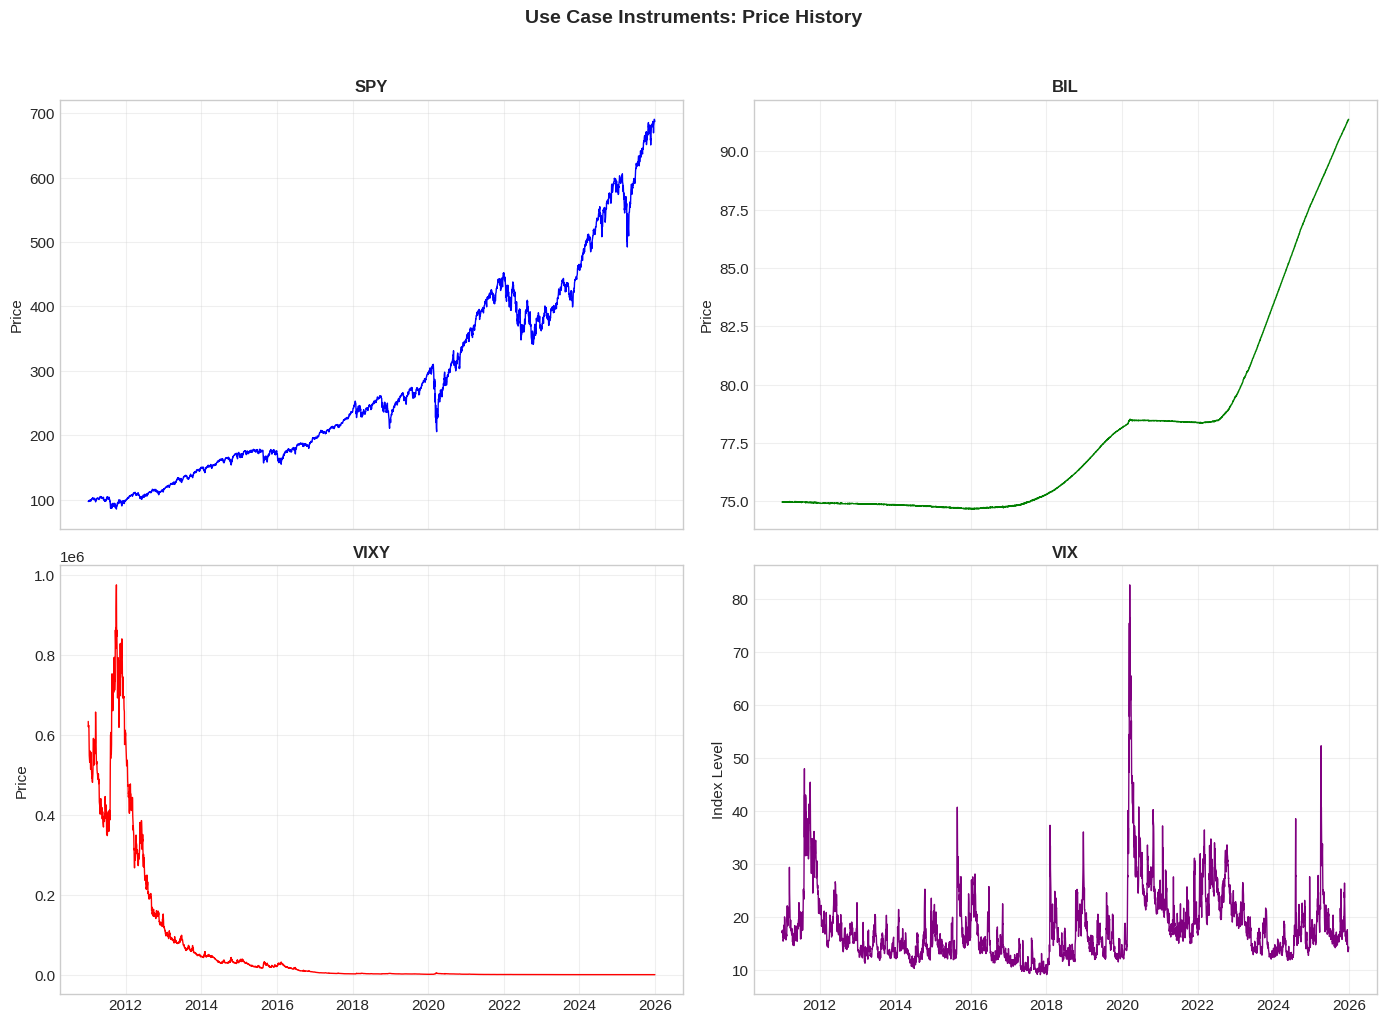

In [8]:
# Subplots for each instrument
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

instruments = ['SPY', 'BIL', 'VIXY', 'VIX']
colors = ['blue', 'green', 'red', 'purple']

for i, (ticker, color) in enumerate(zip(instruments, colors)):
    axes[i].plot(df.index, df[ticker], color=color, linewidth=1)
    axes[i].set_title(ticker, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Price' if ticker != 'VIX' else 'Index Level')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Use Case Instruments: Price History', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**What the price charts reveal:**

- **SPY:** Steady upward trend with periodic drawdowns. The crashes (2020 COVID, 2022 rate hikes) are visible but temporary.
- **BIL:** Flat during the low interest rate era (2011-2021), then rising sharply as the Fed raised rates. BIL tracks short-term Treasury yields, so its price reflects the interest rate environment. Even with the recent rise, total return remains modest.
- **VIXY:** Structural decay is dramatic. The "1e6" scale notation means the y-axis reaches nearly one million dollars (split-adjusted). Today's price is compressed to near zero on this scale. This is not a buy-and-hold instrument.
- **VIX:** Mean-reverting with occasional spikes. It oscillates in a low range most of the time, then explodes during crises (note the 2020 COVID spike to over 80).

### 3.2 VIXY on Log Scale

VIXY's decay is so severe that we need a log scale to see the full picture. On a linear scale, the recent values are compressed to near zero.

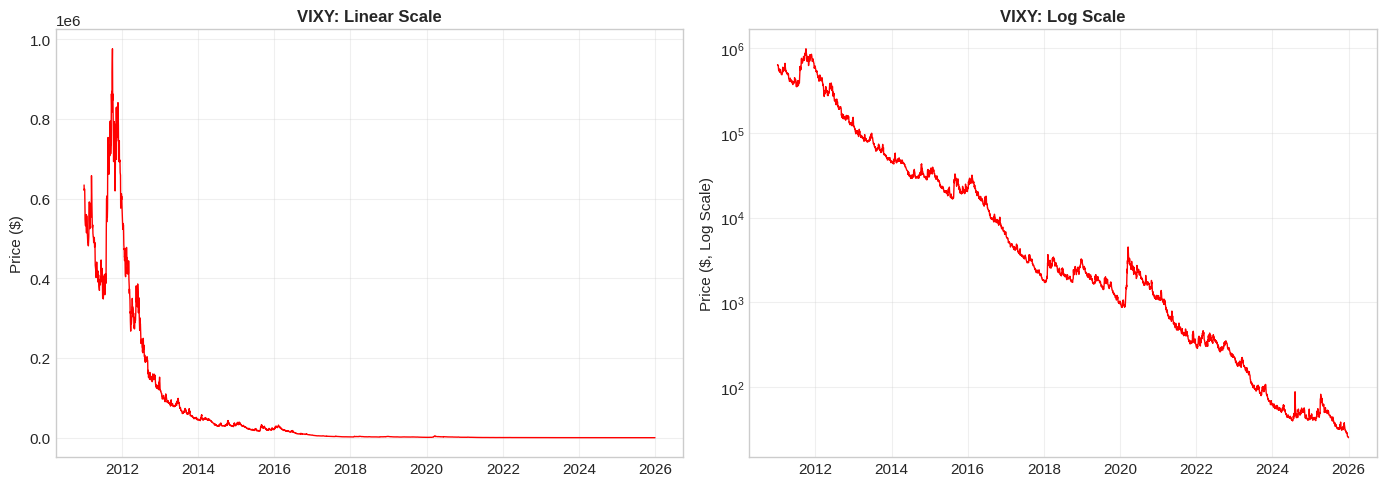

In [9]:
# VIXY on linear vs log scale
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].plot(df.index, df['VIXY'], color='red', linewidth=1)
axes[0].set_title('VIXY: Linear Scale', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].plot(df.index, df['VIXY'], color='red', linewidth=1)
axes[1].set_yscale('log')
axes[1].set_title('VIXY: Log Scale', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price ($, Log Scale)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The log scale reveals the true nature of VIXY: an approximately constant rate of decay punctuated by sharp upward spikes. On the log scale, you can see the spikes (2015, 2018, 2020, 2022) that are invisible on the linear scale.

This visual immediately suggests the trading challenge: how do you capture those spikes while avoiding the relentless downward drift?

This should also highlight why being short volatility is so tempting. If VIXY is in a constant downwards drift, shouldn't you just own SVIX (the inverse of VIXY)?

The answer is: theoretically yes, but practically it is dangerous. Short volatility strategies have destroyed numerous funds and products. The most famous example is XIV, an inverse VIX product that lost 90% of its value in a single day during the February 2018 volatility spike and was subsequently liquidated. The problem is asymmetry working against you: when you are short volatility, your gains are capped (VIXY can only go to zero) but your losses are theoretically unlimited during a spike. A single bad day can erase years of steady gains. This is precisely why we are building a tail hedge strategy rather than a short volatility strategy - we want the asymmetry working in our favor.

### 3.3 Normalized Performance Comparison

To compare relative performance, we normalize all instruments to start at 100.

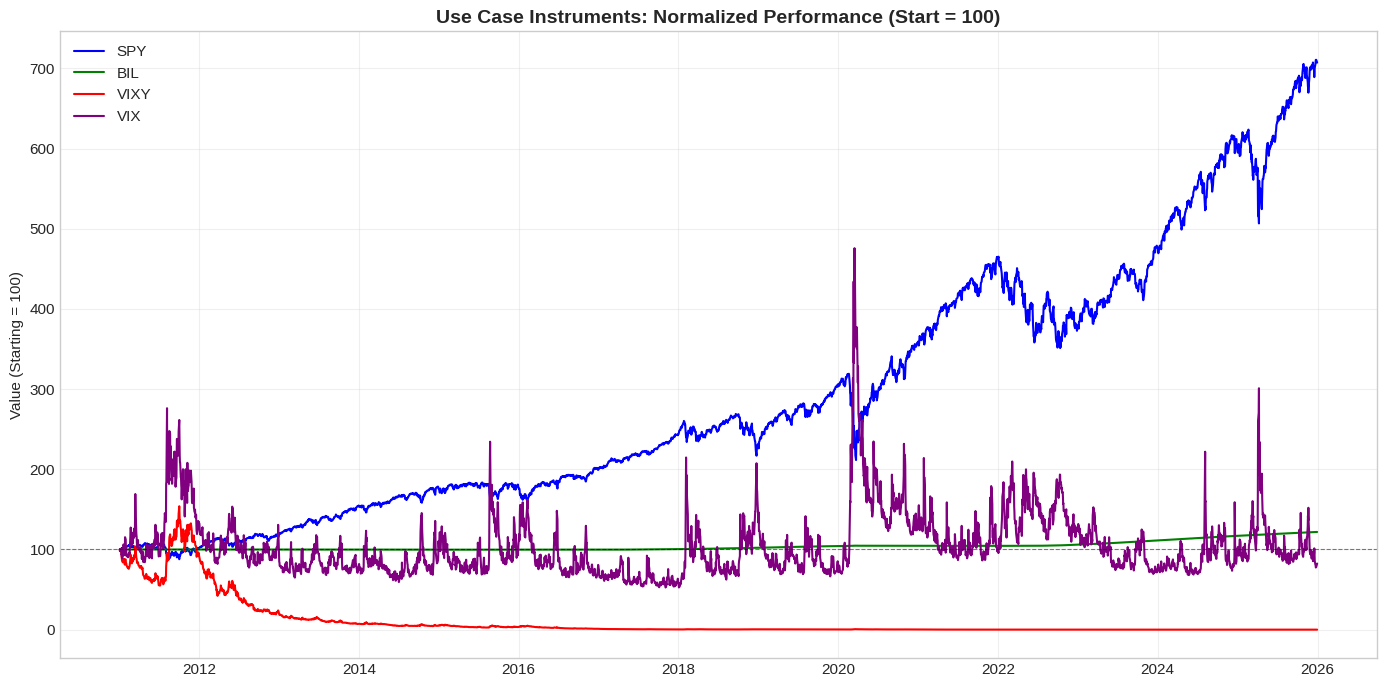

In [10]:
# Normalize to 100
df_normalized = (df / df.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 7))

for ticker, color in zip(instruments, colors):
    ax.plot(df_normalized.index, df_normalized[ticker], color=color, linewidth=1.5, label=ticker)

ax.set_title('Use Case Instruments: Normalized Performance (Start = 100)', fontsize=14, fontweight='bold')
ax.set_ylabel('Value (Starting = 100)')
ax.set_xlabel('')
ax.axhline(y=100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

This chart makes the divergence stark. SPY compounds upward to over 700% of its starting value. BIL shows modest gains, finally moving higher as interest rates rose after 2022. VIXY goes to nearly zero. The VIX oscillates with dramatic spikes (note the 2020 COVID spike nearly hit 500 on this scale) but ends roughly where it started - it is mean-reverting by nature.

Anyone who bought and held VIXY over this period experienced catastrophic losses.

Yet there were moments when VIXY spiked dramatically. The strategy question:

*Can we be in VIXY only during those spikes?*

### 3.4 Normalized Performance (Log Scale)

Log scale helps us see the VIXY spikes that are crushed on the linear chart.

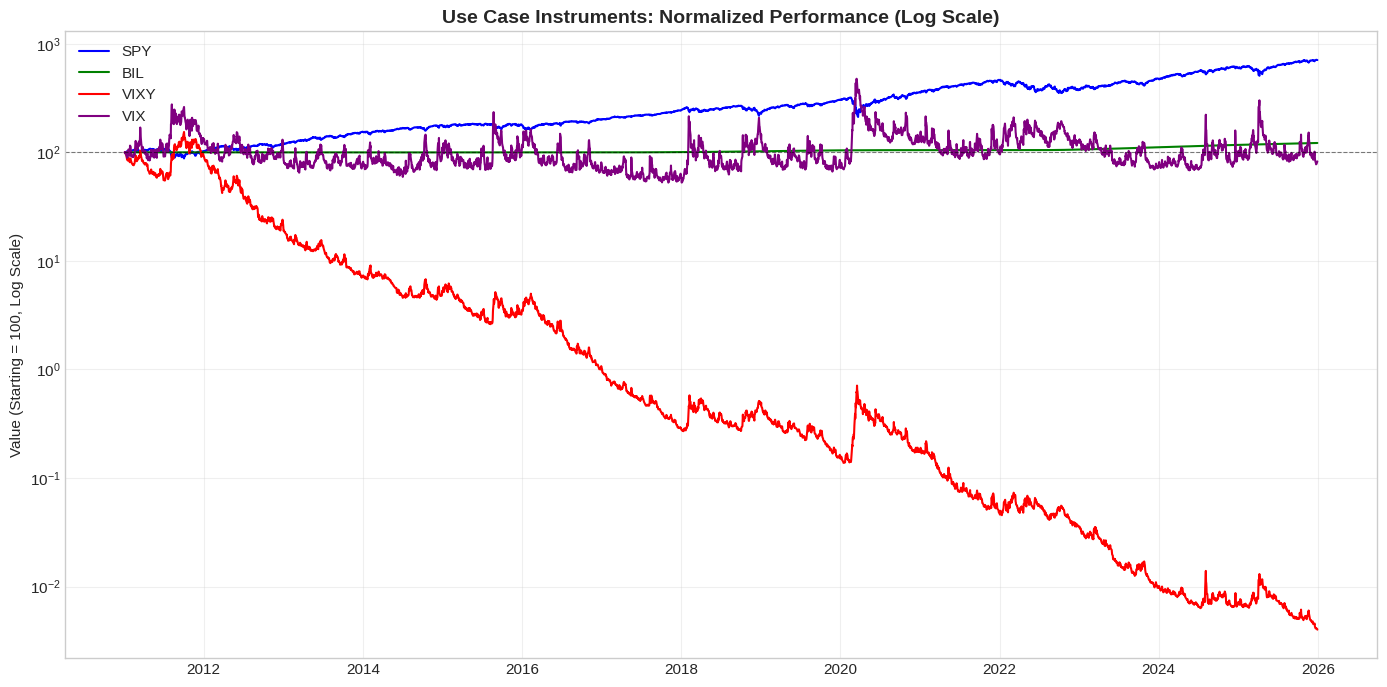

In [11]:
# Normalized performance on log scale
fig, ax = plt.subplots(figsize=(14, 7))

for ticker, color in zip(instruments, colors):
    ax.plot(df_normalized.index, df_normalized[ticker], color=color, linewidth=1.5, label=ticker)

ax.set_yscale('log')
ax.set_title('Use Case Instruments: Normalized Performance (Log Scale)', fontsize=14, fontweight='bold')
ax.set_ylabel('Value (Starting = 100, Log Scale)')
ax.set_xlabel('')
ax.axhline(y=100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

On the log scale, we can see the VIXY spikes clearly as the sawtooth pattern - temporary upward jumps in the otherwise relentless decline. Notice how the spikes coincide with SPY drawdowns (the small dips in the blue line). The 2020 COVID spike is visible as a sharp upward move in VIXY.

But the log scale also reveals the brutal math: VIXY has declined from 100 to below 0.01 on this scale - a loss of over 99.99%. Even the 2020 spike, which was dramatic in the moment, appears as just a brief interruption in the downward trajectory. The magnitude of the decay vastly exceeds the magnitude of the spikes over time.

This is the core challenge: VIXY goes up when SPY goes down, but you need perfect timing to benefit. Hold too long and the decay overwhelms any gains from the spike.


---

## Section 4: Distribution Analysis

The shape of return distributions tells us about the risk characteristics of each instrument.

### 4.1 Return Distributions

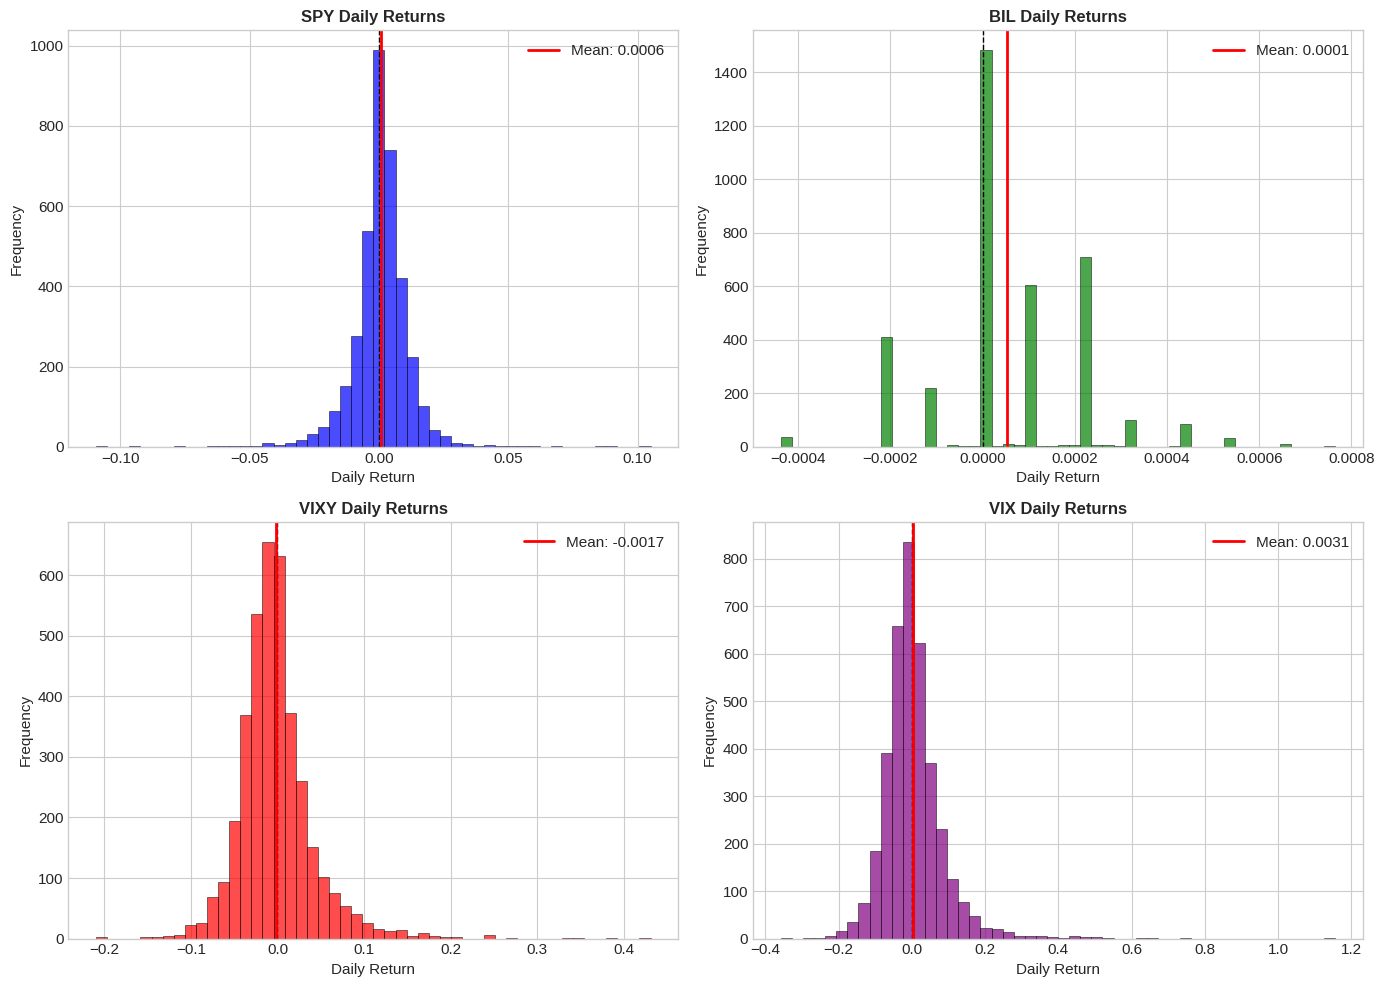

In [12]:
# Histograms of daily returns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (ticker, color) in enumerate(zip(instruments, colors)):
    axes[i].hist(df_returns[ticker], bins=50, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[i].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[i].axvline(x=df_returns[ticker].mean(), color='red', linestyle='-', linewidth=2, label=f'Mean: {df_returns[ticker].mean():.4f}')
    axes[i].set_title(f'{ticker} Daily Returns', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Daily Return')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()

**What the distributions reveal:**

- **SPY:** Roughly symmetric with slight negative skew. The classic equity return distribution with the left tail (losses) extending slightly further than the right.
- **BIL:** Extremely concentrated around zero. The x-axis scale (0.0008 range) compared to others tells the story - this instrument barely moves.
- **VIXY:** Wide distribution with negative mean (shifted left of zero). But notice the long right tail extending past 0.4 - this is the positive skewness at work. VIXY loses money on average, but its best days are more extreme than its worst days. This asymmetry is favorable for hedging.
- **VIX:** Highly asymmetric with an extreme right tail extending past 1.0 (100%+ daily moves). The bulk of readings cluster near zero, but VIX can spike dramatically. It does not move symmetrically; it spikes up suddenly and drifts down gradually.

### 4.2 Comparing SPY and VIXY Distributions

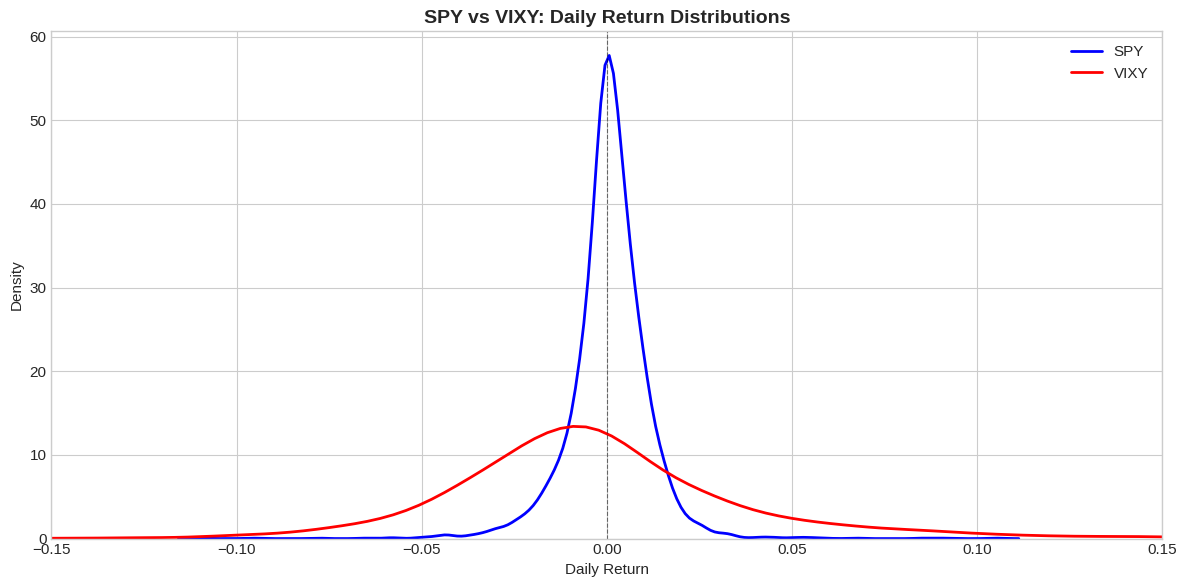

In [13]:
# Overlay SPY and VIXY distributions
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(df_returns['SPY'], ax=ax, color='blue', linewidth=2, label='SPY')
sns.kdeplot(df_returns['VIXY'], ax=ax, color='red', linewidth=2, label='VIXY')

ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('SPY vs VIXY: Daily Return Distributions', fontsize=14, fontweight='bold')
ax.set_xlabel('Daily Return')
ax.set_ylabel('Density')
ax.legend()
ax.set_xlim(-0.15, 0.15)

plt.tight_layout()
plt.show()

The key observation: VIXY has a much wider distribution than SPY (lower peak, fatter tails), and its center is shifted left of zero (negative mean). VIXY is more volatile and loses money on average.

But notice that VIXY's right tail extends further than SPY's - past 0.10 and beyond. On the days when VIXY is up big, it can deliver gains that SPY rarely achieves. This is the positive skewness: VIXY's upside potential on its best days exceeds its downside on its worst days. The challenge is that those best days are rare, while the negative drift is constant.

### 4.3 Box Plot Comparison

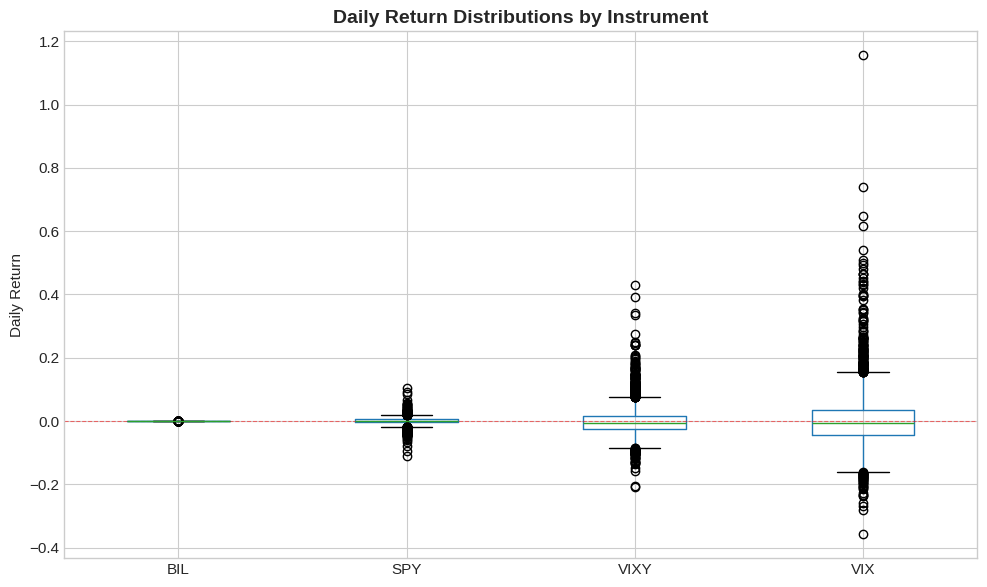

In [14]:
# Box plot for all instruments
fig, ax = plt.subplots(figsize=(10, 6))

df_returns.boxplot(ax=ax)
ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Daily Return Distributions by Instrument', fontsize=14, fontweight='bold')
ax.set_ylabel('Daily Return')
ax.set_xlabel('')

plt.tight_layout()
plt.show()

The box plot confirms what we have seen: VIXY and VIX have the widest distributions with many outliers. BIL is so tight it appears as a line. SPY sits in between. The outliers (circles) show the extreme days that matter most for tail hedging.

---

## Section 5: Correlation and Relationships

Understanding how these instruments relate to each other is crucial for building a hedging strategy.

### 5.1 Correlation Matrix

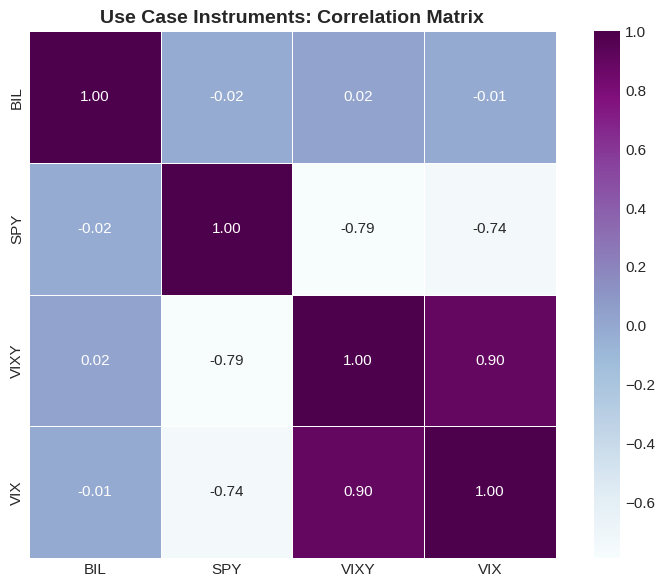

In [15]:
# Correlation matrix
corr_matrix = df_returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='BuPu',
            square=True, linewidths=0.5, ax=ax)

ax.set_title('Use Case Instruments: Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Critical insight:** SPY and VIXY are strongly negatively correlated (-0.79). When SPY goes down, VIXY tends to go up. This is exactly what we need for a hedge, and the relationship is stronger than most asset pairs.
Also note:

VIX and VIXY are highly positively correlated (0.90) - VIXY tracks VIX futures, so this is expected
BIL has near-zero correlation with everything (-0.02 to 0.02) - it truly is neutral cash
SPY and VIX are strongly negatively correlated (-0.74) - the "fear gauge" rises when stocks fall

The -0.79 correlation between SPY and VIXY is remarkably strong and consistent. Compare this to the SPY-TLT correlation we examined earlier, which was near zero and regime-dependent. VIXY offers a more reliable directional hedge.

### 5.2 SPY vs VIXY Scatter Plot

Let us examine the key relationship more closely.

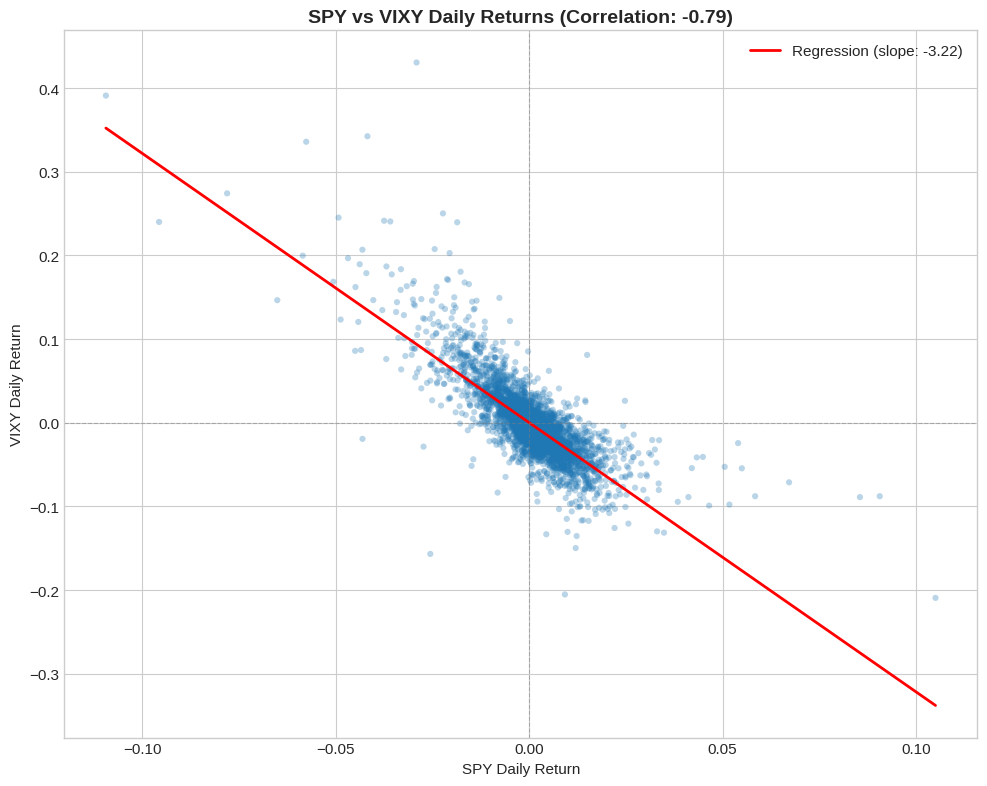

In [16]:
# SPY vs VIXY scatter
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(df_returns['SPY'], df_returns['VIXY'], alpha=0.3, edgecolor='none', s=20)

# Regression line
slope, intercept = np.polyfit(df_returns['SPY'], df_returns['VIXY'], 1)
x_line = np.linspace(df_returns['SPY'].min(), df_returns['SPY'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=2, label=f'Regression (slope: {slope:.2f})')

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

corr = df_returns['SPY'].corr(df_returns['VIXY'])
ax.set_title(f'SPY vs VIXY Daily Returns (Correlation: {corr:.2f})', fontsize=14, fontweight='bold')
ax.set_xlabel('SPY Daily Return')
ax.set_ylabel('VIXY Daily Return')
ax.legend()

plt.tight_layout()
plt.show()

The negative slope (-3.22) confirms the hedging relationship: when SPY falls, VIXY rises. The slope tells us that for every 1% SPY drops, VIXY rises approximately 3.2% on average. This leverage amplifies the hedge.

Notice the asymmetry in the scatter. The upper-left quadrant (SPY down, VIXY up) shows VIXY gains extending above 0.40, while the lower-right quadrant (SPY up, VIXY down) shows VIXY losses rarely exceeding -0.20. VIXY responds more dramatically to SPY drops than to SPY gains. This asymmetry is favorable for hedging: you get more protection on bad days than you give up on good days.

Also notice the outliers in the upper-left corner - these are the crisis days when holding VIXY would have delivered spectacular returns as the market crashed.

### 5.3 SPY vs VIX Scatter Plot

Let us also look at the relationship between SPY and VIX (the index itself).

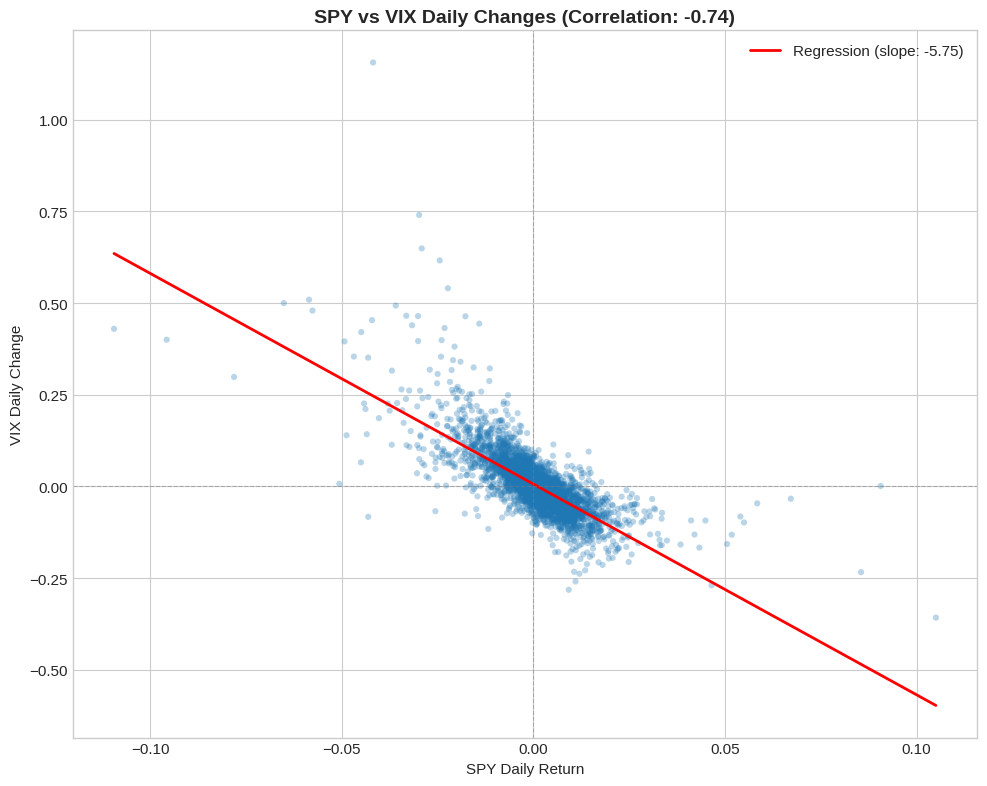

In [17]:
# SPY vs VIX scatter
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(df_returns['SPY'], df_returns['VIX'], alpha=0.3, edgecolor='none', s=20)

# Regression line
slope, intercept = np.polyfit(df_returns['SPY'], df_returns['VIX'], 1)
x_line = np.linspace(df_returns['SPY'].min(), df_returns['SPY'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=2, label=f'Regression (slope: {slope:.2f})')

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

corr = df_returns['SPY'].corr(df_returns['VIX'])
ax.set_title(f'SPY vs VIX Daily Changes (Correlation: {corr:.2f})', fontsize=14, fontweight='bold')
ax.set_xlabel('SPY Daily Return')
ax.set_ylabel('VIX Daily Change')
ax.legend()

plt.tight_layout()
plt.show()

The SPY-VIX relationship is even stronger than SPY-VIXY. The VIX is a more direct measure of market fear. When stocks drop, fear rises. This relationship is one of the most reliable in financial markets.

### 5.4 Rolling Correlation: SPY vs VIXY

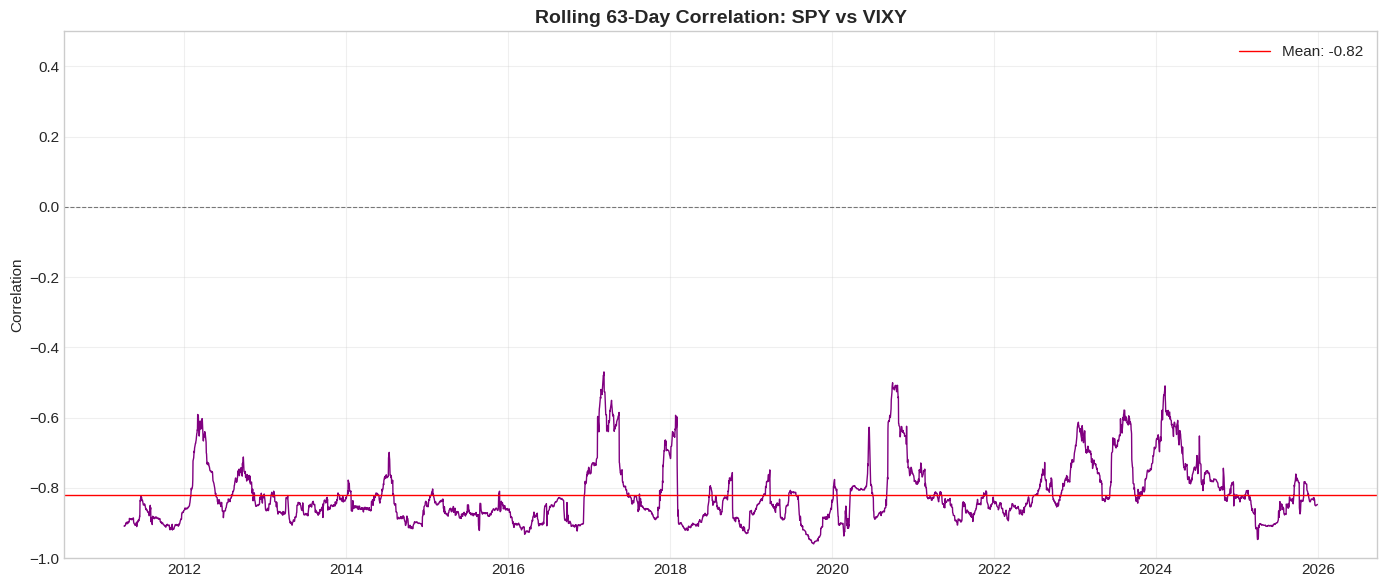

In [18]:
# Rolling 63-day (quarterly) correlation
rolling_window = 63
rolling_corr = df_returns['SPY'].rolling(window=rolling_window).corr(df_returns['VIXY'])

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(rolling_corr.index, rolling_corr, linewidth=1, color='purple')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=rolling_corr.mean(), color='red', linestyle='-', linewidth=1,
           label=f'Mean: {rolling_corr.mean():.2f}')

ax.set_title(f'Rolling {rolling_window}-Day Correlation: SPY vs VIXY', fontsize=14, fontweight='bold')
ax.set_ylabel('Correlation')
ax.set_xlabel('')
ax.set_ylim(-1, 0.5)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The rolling correlation between SPY and VIXY is consistently negative, never once crossing into positive territory over the entire period. The mean of -0.82 is remarkably stable, with the correlation ranging between roughly -0.9 and -0.5.

Compare this to the SPY-TLT relationship we examined in Notebook 4.2, which flipped from negative to positive after 2021. The SPY-VIXY relationship is structurally negative - it is built into the mechanics of how VIX futures behave when equities sell off.

The occasional spikes toward -0.5 (weaker negative correlation) tend to occur during calm, low-volatility periods when both SPY and VIXY drift without dramatic moves. When volatility returns, the correlation strengthens again. This makes VIXY a reliable directional hedge, though the cost of holding it during calm periods remains the challenge we need to solve.

---

## Section 6: The VIX as a Signal

The VIX is often used as a signal for market conditions. Let us examine its characteristics more closely.

### 6.1 VIX Level Distribution

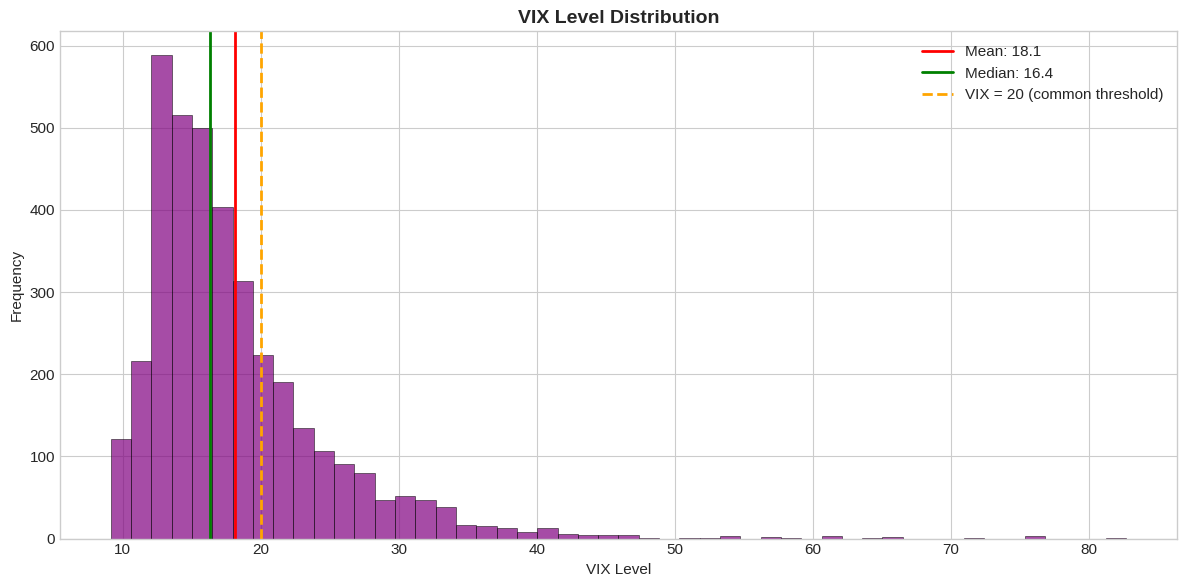

In [19]:
# VIX level distribution (not returns, but actual levels)
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df['VIX'], bins=50, color='purple', alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axvline(x=df['VIX'].mean(), color='red', linestyle='-', linewidth=2, label=f'Mean: {df["VIX"].mean():.1f}')
ax.axvline(x=df['VIX'].median(), color='green', linestyle='-', linewidth=2, label=f'Median: {df["VIX"].median():.1f}')
ax.axvline(x=20, color='orange', linestyle='--', linewidth=2, label='VIX = 20 (common threshold)')

ax.set_title('VIX Level Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('VIX Level')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

The VIX distribution is highly skewed. Most of the time, VIX sits in the 12-20 range (low fear), with the peak frequency around 12-14. The long right tail extends past 80, representing rare crisis periods.

The difference between mean (18.1) and median (16.4) quantifies the skewness: the mean is pulled up by extreme spikes while the median reflects typical conditions. More than half of all trading days have VIX below 16.4.

A VIX level of 20 is often used as a threshold for "elevated" volatility. Looking at the distribution, you can see that the VIX = 20 line sits to the right of both the mean and median, meaning readings above 20 are already in the upper portion of the distribution. Readings above 30 are clearly in tail territory, and readings above 40 are rare crisis events.

This distribution suggests a natural question: if we only hold VIXY when VIX is elevated (say, above 20), do we avoid most of the decay while capturing the spikes?

### 6.2 VIX Regimes and SPY Returns

Do SPY returns differ depending on the VIX level? Let us categorize days by VIX regime.

In [20]:
# Create VIX regime categories
df_analysis = df_returns.copy()
df_analysis['VIX_Level'] = df['VIX'].shift(1)  # Use previous day's VIX to avoid look-ahead

# Define regimes
def vix_regime(vix):
    if vix < 15:
        return 'Low (< 15)'
    elif vix < 20:
        return 'Normal (15-20)'
    elif vix < 30:
        return 'Elevated (20-30)'
    else:
        return 'High (> 30)'

df_analysis['VIX_Regime'] = df_analysis['VIX_Level'].apply(vix_regime)
df_analysis = df_analysis.dropna()

# Calculate statistics by regime
regime_stats = df_analysis.groupby('VIX_Regime').agg({
    'SPY': ['mean', 'std', 'count'],
    'VIXY': ['mean', 'std']
}).round(4)

regime_stats.columns = ['SPY Mean', 'SPY Std', 'Days', 'VIXY Mean', 'VIXY Std']

# Reorder rows
regime_order = ['Low (< 15)', 'Normal (15-20)', 'Elevated (20-30)', 'High (> 30)']
regime_stats = regime_stats.reindex(regime_order)

regime_stats

,SPY Mean,SPY Std,Days,VIXY Mean,VIXY Std
VIX_Regime,,,,,
Low (< 15),0.0004,0.0055,1432,-0.0013,0.0288
Normal (15-20),0.0003,0.0087,1317,-0.0005,0.0439
Elevated (20-30),0.0007,0.0131,789,-0.0042,0.0549
High (> 30),0.0026,0.0265,231,-0.0035,0.0732


**Key observations:**

- SPY has positive average returns across all VIX regimes, but volatility increases dramatically from 0.55% in Low to 2.65% in High regimes. The risk is concentrated in elevated environments.
- VIXY has negative average returns across all regimes, reflecting continuous decay. However, notice that VIXY's volatility increases substantially in elevated regimes (5.49% to 7.32%). This higher dispersion means bigger moves in both directions - including the sharp spikes that provide crash protection.
- Most days occur in the Low and Normal regimes (about 73% of the sample). High VIX days are rare (6%) but consequential.

This suggests a potential strategy: avoid holding VIXY in low VIX environments where decay dominates and volatility is low. When VIX is elevated, you are positioned to capture the spikes when they occur, accepting some decay in exchange for crash protection when it matters most.

### 6.3 Visualizing Returns by VIX Regime

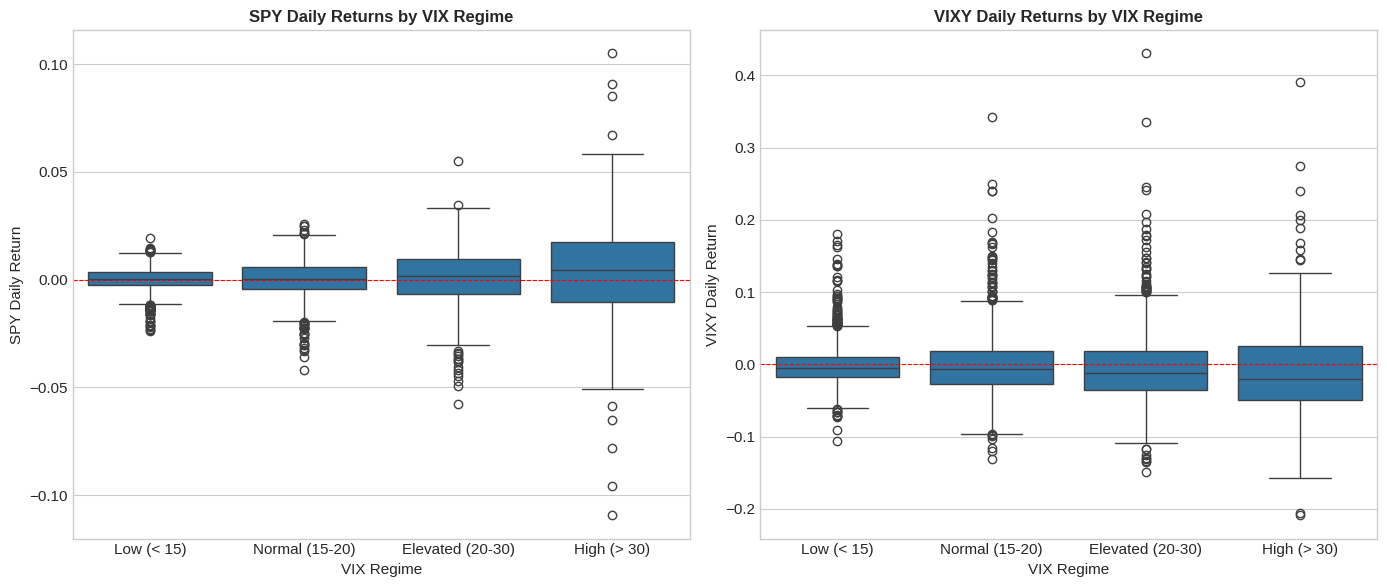

In [21]:
# Box plot of SPY returns by VIX regime
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SPY returns by regime
order = ['Low (< 15)', 'Normal (15-20)', 'Elevated (20-30)', 'High (> 30)']
sns.boxplot(data=df_analysis, x='VIX_Regime', y='SPY', order=order, ax=axes[0])
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title('SPY Daily Returns by VIX Regime', fontsize=12, fontweight='bold')
axes[0].set_xlabel('VIX Regime')
axes[0].set_ylabel('SPY Daily Return')

# VIXY returns by regime
sns.boxplot(data=df_analysis, x='VIX_Regime', y='VIXY', order=order, ax=axes[1])
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=0.8)
axes[1].set_title('VIXY Daily Returns by VIX Regime', fontsize=12, fontweight='bold')
axes[1].set_xlabel('VIX Regime')
axes[1].set_ylabel('VIXY Daily Return')

plt.tight_layout()
plt.show()

The box plots confirm the regime differences:

- SPY has similar median returns across regimes (near zero), but the spread (box height) and outliers increase dramatically in elevated and high VIX environments. The High regime shows both the largest gains (outliers above 0.10) and largest losses (outliers near -0.10).
- VIXY shows median returns below zero in all regimes - the median line sits below the red dashed line in every box. However, look at the outliers: the upside outliers extend to 0.40+ in the Elevated and High regimes. These are the crisis spike days. In the Low regime, the upside outliers barely reach 0.10.

The visual evidence supports a regime-based approach: while VIXY's median return is negative across all regimes, the potential for large positive outliers is concentrated in elevated and high VIX environments. That is where the tail hedge payoffs occur.

---

## Section 7: Range Plot for Use Case Instruments

In [22]:
def range_plot(df, title='Range Plot', x_axis_label='Value'):
    """
    Create a range plot showing min, max, percentiles, mean, and current value.
    """
    # Calculate statistics
    min_val = df.min()
    max_val = df.max()
    perc5 = df.quantile(0.05)
    perc95 = df.quantile(0.95)
    mean_val = df.mean()
    current = df.iloc[-1]

    # Sort by mean for better visualization
    sort_order = mean_val.sort_values().index

    fig, ax = plt.subplots(figsize=(12, 6))

    y_positions = range(len(sort_order))

    for i, asset in enumerate(sort_order):
        # Full range bar (min to max) - light color
        ax.barh(i, max_val[asset] - min_val[asset], left=min_val[asset],
                height=0.6, color='lightblue', edgecolor='black', linewidth=0.5)

        # Tail regions (below 5th and above 95th percentile) - darker color
        ax.barh(i, perc5[asset] - min_val[asset], left=min_val[asset],
                height=0.6, color='steelblue', alpha=0.7)
        ax.barh(i, max_val[asset] - perc95[asset], left=perc95[asset],
                height=0.6, color='steelblue', alpha=0.7)

        # Mean marker
        ax.scatter(mean_val[asset], i, color='red', s=100, zorder=5, marker='o')

        # Current value marker
        ax.scatter(current[asset], i, color='green', s=100, zorder=5, marker='D')

    # Labels
    ax.set_yticks(y_positions)
    ax.set_yticklabels(sort_order)
    ax.set_xlabel(x_axis_label)
    ax.set_title(title, fontsize=14, fontweight='bold')

    # Legend
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor='lightblue', edgecolor='black', label='Full Range (Min to Max)'),
        Patch(facecolor='steelblue', alpha=0.7, label='Tail Regions (< 5th, > 95th percentile)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Mean'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='green', markersize=10, label='Current')
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    ax.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    return fig, ax

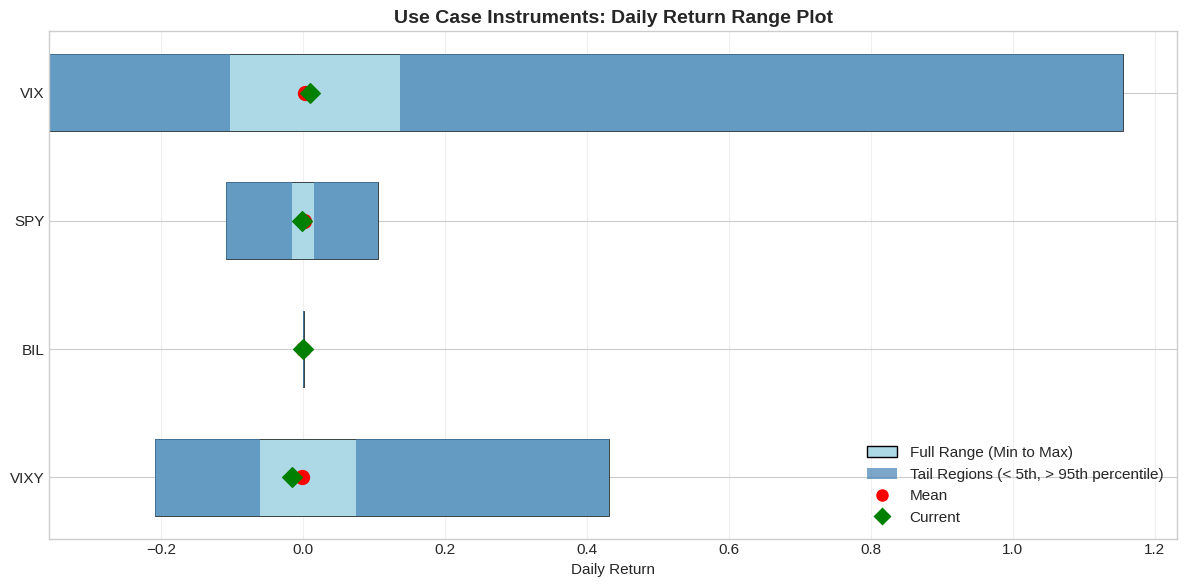

In [23]:
# Range plot for daily returns
fig, ax = range_plot(df_returns,
                     title='Use Case Instruments: Daily Return Range Plot',
                     x_axis_label='Daily Return')
plt.show()

The Range Plot summarizes what we have learned:

VIX: The widest range by far, extending past 1.0 (100%+ daily changes). This is the volatility of volatility itself. Not tradeable, but it shows the magnitude of potential moves.
SPY: Moderate range roughly symmetric around zero, with mean slightly positive. The typical equity profile.
BIL: Barely visible. Tiny range, negligible variability. This is cash.
VIXY: Wide range but notably asymmetric - the right tail extends to 0.4+ while the left tail only reaches about -0.2. Mean is negative (red dot left of zero). This asymmetry is the positive skewness we discussed: bigger up days than down days, despite losing money on average.

The current values (green diamonds) show where the latest day sits relative to history. All four are near their means, indicating a typical, unremarkable day.

---

## Section 8: Forming the Trading Hypothesis

Based on our EDA, we can now articulate hypotheses to test in subsequent chapters.

### Summary of Key Findings

**About VIXY:**
1. VIXY has a strongly negative expected return due to structural decay
2. VIXY is negatively correlated with SPY, making it a potential hedge
3. The negative correlation is relatively stable over time
4. VIXY spikes dramatically during market crashes

**About VIX as a signal:**
1. VIX is mean-reverting, spending most time in a low range with occasional spikes
2. When VIX is low, VIXY decays; when VIX is elevated, VIXY may offer positive returns
3. VIX level can potentially be used to time exposure to VIXY

**About the instruments together:**
1. BIL provides a safe place to park capital when not holding VIXY
2. SPY is the asset we want to protect from tail risk
3. The challenge is capturing VIXY's crisis spikes while avoiding its decay

### Trading Hypothesis

Based on this analysis, our hypothesis for testing is:

> **A strategy that holds VIXY only when the VIX is above a threshold (indicating elevated fear) and holds BIL otherwise may capture the hedging benefit of VIXY while avoiding most of its structural decay.**

In the next chapters, we will formalize this hypothesis into a testable strategy and evaluate its performance.

---

## Notebook Summary

In this notebook, we applied EDA techniques to our volatility tail hedge use case:

**Instrument Analysis:**
- Examined numerical summaries revealing VIXY's decay and volatility
- Visualized price histories showing divergent long-term paths
- Used log scale to reveal VIXY spike patterns

**Distribution Analysis:**
- Compared return distributions across instruments
- Identified the asymmetric nature of VIX movements

**Relationship Analysis:**
- Confirmed negative SPY-VIXY correlation (hedging potential)
- Examined correlation stability over time
- Analyzed SPY and VIXY behavior across VIX regimes

**Hypothesis Formation:**
- Developed a testable trading hypothesis based on visual evidence
- Identified VIX level as a potential timing signal

**Key takeaways:**
1. EDA is not just about making charts; it is about forming testable hypotheses
2. Understanding instrument characteristics is essential before building strategies
3. Visual analysis reveals patterns that summary statistics miss
4. The VIX regime appears to influence VIXY's return characteristics

In the next chapter, we will take this hypothesis and formalize it into a backtestable strategy.